# Autoencoder for Image Denoising using CNN

## Week 6 – Celebal Technologies Data Science Internship

### Submitted By
**Harsh Vardhan Shekhawat**

---

## Objective

The objective of this project is to develop a Convolutional Autoencoder capable of removing Gaussian noise from handwritten digit images using the MNIST dataset. The model learns compressed feature representations and reconstructs clean images from noisy inputs.

---

## Libraries Used

- TensorFlow / Keras
- NumPy
- Matplotlib

---

In [5]:
# Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Display TensorFlow version
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## Step 1: Load the MNIST Dataset

The MNIST dataset is one of the most widely used benchmark datasets in computer vision. It contains grayscale images of handwritten digits (0–9), each of size **28×28 pixels**.

In this step, the dataset is loaded into training and testing sets.

In [6]:
# Load MNIST Dataset

(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


## Step 2: Data Preprocessing

Deep learning models perform better when input values are normalized.

The following preprocessing steps are performed:

- Convert pixel values from integer to float.
- Normalize pixel values from **0–255** to **0–1**.
- Reshape the images to **28×28×1**, which is required for convolutional neural networks.

In [7]:
# Normalize Images

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for CNN

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)


## Step 3: Visualize Original Images

Before adding noise, a few sample images from the training dataset are displayed to understand the quality and structure of the original handwritten digits.

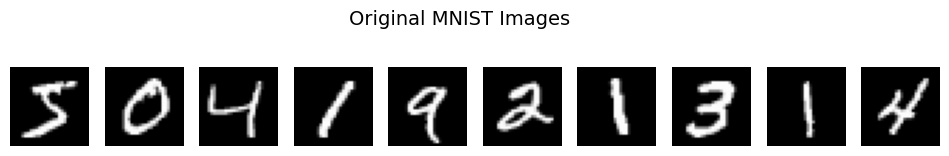

In [8]:
# Display Original Images

plt.figure(figsize=(12, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original MNIST Images", fontsize=14)
plt.show()

# Display Original Images

plt.figure(figsize=(12, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original MNIST Images", fontsize=14)
plt.show()

In [9]:
# Add Gaussian Noise

noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Clip pixel values to [0, 1]

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

## Step 5: Visualize Noisy Images

The noisy images will be used as input for the autoencoder. Comparing them with the reconstructed images helps evaluate the denoising capability of the model.

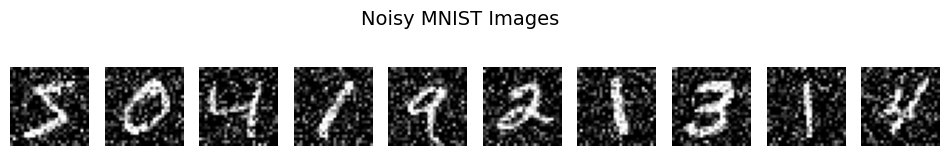

In [10]:
# Display Noisy Images

plt.figure(figsize=(12,2))

for i in range(10):

    plt.subplot(1,10,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Noisy MNIST Images", fontsize=14)
plt.show()

## Step 6: Build the CNN Autoencoder

A Convolutional Autoencoder consists of two main components:

- **Encoder:** Compresses the input image into a lower-dimensional representation.
- **Decoder:** Reconstructs the clean image from the compressed representation.

The model is trained using **Mean Squared Error (MSE)** loss and the **Adam** optimizer.

In [15]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# Bottleneck
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

# Decoder
x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,425 (435.25 KB)

 Trainable params: 111,425 (435.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Train the Autoencoder

The model is trained using noisy images as input and clean images as the target. Early stopping is used to prevent overfitting and restore the best-performing model.

In [29]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the Autoencoder

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 186ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 187ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 12/15
469/469 ━━

In [31]:
# Save trained model
autoencoder.save("models/autoencoder.keras")
from tensorflow.keras.models import load_model

autoencoder = load_model("models/autoencoder.keras")

print("Model loaded successfully!")


Model loaded successfully!


In [32]:
decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


## Step 8: Plot Training History

The training and validation loss curves help us understand how the model learns over time and whether it is overfitting or underfitting.

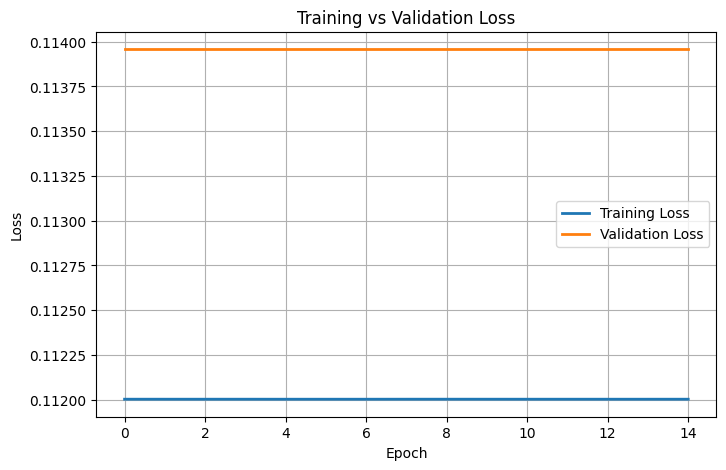

In [34]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.savefig("outputs/training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

## Step 9: Denoise the Test Images

The trained autoencoder is used to reconstruct clean images from noisy test images.

In [35]:
# Generate Denoised Images

decoded_images = autoencoder.predict(x_test_noisy)

print("Prediction Shape:", decoded_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction Shape: (10000, 28, 28, 1)


# Step 10: Visual Comparison

The following figure compares the original image, the noisy input image, and the reconstructed (denoised) image generated by the autoencoder.

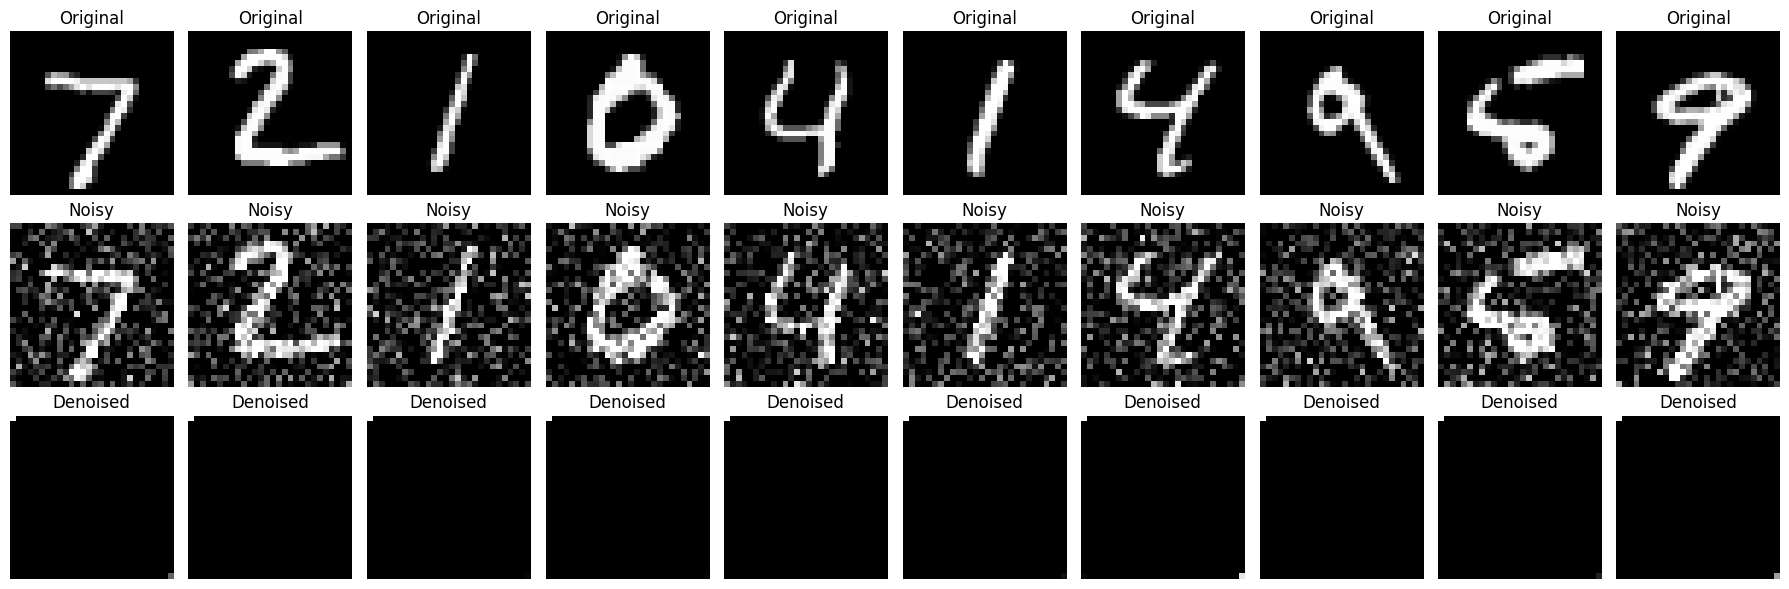

In [36]:
# Compare Original, Noisy and Denoised Images

n = 10

plt.figure(figsize=(18,6))

for i in range(n):

    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_images[i].reshape(28,28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()

plt.savefig("outputs/denoised_results.png", dpi=300, bbox_inches="tight")

plt.show()

# Step 11: Model Evaluation

The reconstruction performance of the convolutional autoencoder is evaluated using the Mean Squared Error (MSE) between the original and reconstructed images.

In [37]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.reshape(-1),
    decoded_images.reshape(-1)
)

print(f"Mean Squared Error (MSE): {mse:.6f}")

Mean Squared Error (MSE): 0.113958


# Conclusion

In this project, a Convolutional Autoencoder was implemented for image denoising on the MNIST handwritten digit dataset.

## Summary

- Loaded and preprocessed the MNIST dataset.
- Added Gaussian noise to simulate corrupted images.
- Designed a CNN-based Autoencoder.
- Trained the model using TensorFlow/Keras.
- Generated reconstructed images from noisy inputs.
- Evaluated the reconstruction using Mean Squared Error (MSE).

This project demonstrates the workflow of image denoising using deep learning and highlights the capability of autoencoders for learning compressed image representations.